### Authors
- David Robredo Manuel
- Duarte Novas Álvarez
- Rubén González Braña

### Import libraries

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

2025-04-03 16:57:52.785062: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-03 16:57:52.811237: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743692272.828230 3808904 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743692272.833378 3808904 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-03 16:57:52.850616: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

### Functions and utilities

In [2]:
np.random.seed(42)

In [3]:
#reads a file. Each line has the format: label text
#Returns a list with the text and a list with the labels
def readData(fname):

    with open(fname, 'r', encoding="utf-8") as f:
        fileData = f.read()
  
    lines = fileData.split("\n")
    textData = list()
    textLabel = list()
    lineLength = np.zeros(len(lines))
    
    for i, aLine in enumerate(lines):     
        if not aLine:
            break  
        label = aLine.split(" ")[0]
        lineLength[i] = len(aLine.split(" "))
        if(label == "__label__1"):
            textLabel.append(0)
            textData.append(aLine.removeprefix("__label__1 "))

        elif(label == "__label__2"):
            textLabel.append(1)
            textData.append(aLine.removeprefix("__label__2 "))

        else:
            print("\nError in readData: ", i, aLine)
            exit()
    
    f.close()
    return textData, textLabel, int(np.average(lineLength)+2*np.std(lineLength))

In [4]:
from tensorflow.keras.layers import TextVectorization

def transformData(x_train, y_train, x_test, y_test, maxFeatures, seqLength):
    #transforms text input to int input based on the vocabulary
    #max_tokens = maxFeatures is the size of the vocabulary
    #output_sequence_length =  seqLength is the maximum length of the transformed text. Adds 0 is text length is shorter
    precLayer = TextVectorization(max_tokens = maxFeatures, 
    standardize =  'lower_and_strip_punctuation', split = 'whitespace', output_mode = 'int', 
    output_sequence_length =  seqLength)
    precLayer.adapt(x_train)
    #print(precLayer.get_vocabulary())
    x_train_int = precLayer(x_train)
    y_train = tf.convert_to_tensor(y_train)
    #print(x_train_int)
    #print(y_train)
    x_test_int= precLayer(x_test)
    y_test = tf.convert_to_tensor(y_test)
    #print(x_test_int)
    #print(y_test)

    return x_train_int, y_train, x_test_int, y_test

### Loading the data

In [5]:
x_train, y_train, seqLength = readData("amazon/train_small.txt")
x_test, y_test, tmp = readData("amazon/test_small.txt")

#maxFeatures is a hyperparameter
maxFeatures = 10000

x_train_int, y_train, x_test_int, y_test = transformData(x_train, y_train, x_test, y_test, maxFeatures, seqLength)

I0000 00:00:1743692286.643559 3808904 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13760 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:17:00.0, compute capability: 7.5


### Creating the models

**MODEL 1**

To start we create the first model architecture approach with few Keras layers such as one bidirectional LSTM, and adding a Dropout layer after that so it can learn properly without getting into overfitting.

In [6]:
model1 = keras.Sequential()
model1.add(layers.Input(shape=(seqLength,)))
model1.add(layers.Embedding(input_dim=maxFeatures, output_dim=128, input_length=seqLength))
model1.add(layers.Bidirectional(layers.LSTM(128)))
model1.add(layers.Dropout(0.5))
model1.add(layers.Dense(1, activation='sigmoid'))

model1.summary()

/home/ulc/cursos/curso281/.conda/envs/mia-dl2/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 166, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,543,425 (5.89 MB)

 Trainable params: 1,543,425 (5.89 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

**MODEL 2**

The second architecture introduces more bidirectional LSTM before the dropout to study how the results are evolving.

In [8]:
model2 = keras.Sequential()
model2.add(layers.Input(shape=(seqLength,)))
model2.add(layers.Embedding(input_dim=maxFeatures, output_dim=128, input_length=seqLength))
model2.add(layers.Bidirectional(layers.LSTM(16, return_sequences=True)))
model2.add(layers.Bidirectional(layers.LSTM(16, return_sequences=True)))
model2.add(layers.Bidirectional(layers.LSTM(16)))
model2.add(layers.Dropout(0.5))
model2.add(layers.Dense(1, activation='sigmoid'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 166, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 166, 32)        │        18,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 166, 32)        │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,311,137 (5.00 MB)

 Trainable params: 1,311,137 (5.00 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

**MODEL 3**

For the third model we try to change the architecture a bit, introducing one GRU bidirectional layer instead of the previous LSTM performed.

In [10]:
model3 = keras.Sequential()
model3.add(layers.Input(shape=(seqLength,)))
model3.add(layers.Embedding(input_dim=maxFeatures, output_dim=128, input_length=seqLength))
model3.add(layers.Bidirectional(layers.GRU(128)))
model3.add(layers.Dropout(0.5))
model3.add(layers.Dense(1, activation='sigmoid'))

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 166, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 256)            │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,478,401 (5.64 MB)

 Trainable params: 1,478,401 (5.64 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model3.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

**MODEL 4**

Now we are going to consider both GRU and LSTM in the architecture to see if this architecture improve the results.

In [ ]:
model4 = keras.Sequential()
model4.add(layers.Input(shape=(seqLength,)))
model4.add(layers.Embedding(input_dim=maxFeatures, output_dim=128, input_length=seqLength))
model4.add(layers.GRU(128, activation='tanh', return_sequences=True))
model4.add(layers.LSTM(16, return_sequences=True))
model4.add(layers.GRU(16))
model4.add(layers.Dense(1, activation='sigmoid'))

model4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 166, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 166, 128)       │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 166, 16)        │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 16)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,390,001 (5.30 MB)

 Trainable params: 1,390,001 (5.30 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

**MODEL 5**

Finally, we are changing the architecture to deal with different sucessive Convolutional and MaxPooling layers. By using that, again it will be studied if this architecture affects positively to the results.

In [14]:
model5 = keras.Sequential()
model5.add(layers.Input(shape=(seqLength,)))
model5.add(layers.Embedding(input_dim=maxFeatures, output_dim=128, input_length=seqLength))
model5.add(layers.Conv1D(128, 3, activation='relu'))
model5.add(layers.MaxPooling1D(2))
model5.add(layers.Conv1D(128, 3, activation='relu'))
model5.add(layers.MaxPooling1D(2))
model5.add(layers.Bidirectional(layers.LSTM(128)))
model5.add(layers.Dropout(0.5))
model5.add(layers.Dense(1, activation='sigmoid'))

model5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 166, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 164, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 82, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 80, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 40, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,641,985 (6.26 MB)

 Trainable params: 1,641,985 (6.26 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model5.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### Training and saving the models

In [16]:
# Creating early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', mode="max", patience=3, restore_best_weights=True)

**MODEL 1**

Epoch 1/10


I0000 00:00:1743692302.531604 3808941 cuda_dnn.cc:529] Loaded cuDNN version 90300


313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.7137 - loss: 0.5323 - val_accuracy: 0.8674 - val_loss: 0.3106
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9151 - loss: 0.2260 - val_accuracy: 0.8774 - val_loss: 0.2960
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9412 - loss: 0.1596 - val_accuracy: 0.8688 - val_loss: 0.3179
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9600 - loss: 0.1246 - val_accuracy: 0.8672 - val_loss: 0.3561
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9675 - loss: 0.0999 - val_accuracy: 0.8572 - val_loss: 0.4937


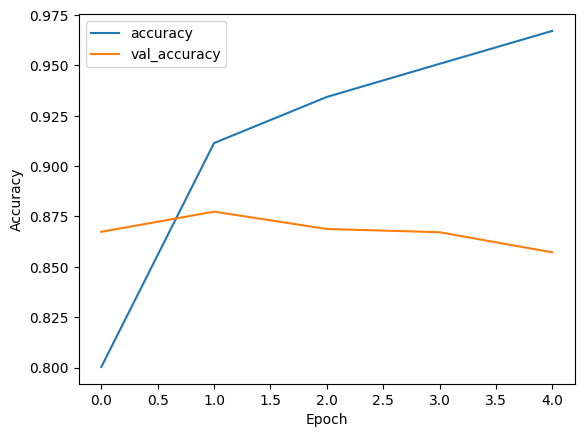

In [17]:
history1 = model1.fit(x_train_int, y_train, epochs=10, batch_size=64, validation_split=0.2, callbacks=[early_stopping])

plt.plot(history1.history['accuracy'], label='accuracy')
plt.plot(history1.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

After the training, we can see that the model stops to perform in epoch 5 due to the early stopping, ending with an validation accuracy of around 87% which represent a quite good performance.

In [ ]:
model1.save('model_1.h5')

In [18]:
history_df = pd.DataFrame(history1.history)
history_df.to_csv('training_history_model_1.csv', index=False)

**MODEL 2**

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.6987 - loss: 0.5385 - val_accuracy: 0.8392 - val_loss: 0.3625
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9255 - loss: 0.2228 - val_accuracy: 0.8736 - val_loss: 0.3076
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9568 - loss: 0.1380 - val_accuracy: 0.8678 - val_loss: 0.3453
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9770 - loss: 0.0821 - val_accuracy: 0.8618 - val_loss: 0.4139
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9848 - loss: 0.0597 - val_accuracy: 0.8520 - val_loss: 0.4731


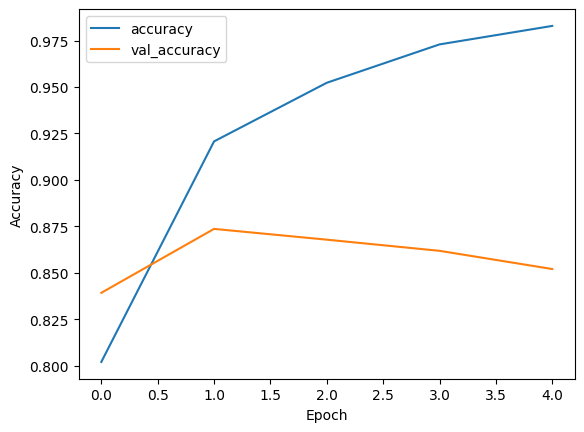

In [19]:
history2 = model2.fit(x_train_int, y_train, epochs=10, batch_size=64, validation_split=0.2, callbacks=[early_stopping])

plt.plot(history2.history['accuracy'], label='accuracy')
plt.plot(history2.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Results presented by this model are similar to the previous ones, showing almost the same accuracy performing the same number of epochs.

In [ ]:
model2.save('model_2.h5')

In [20]:
history_df = pd.DataFrame(history2.history)
history_df.to_csv('training_history_model_2.csv', index=False)

**MODEL 3**

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7340 - loss: 0.5157 - val_accuracy: 0.8406 - val_loss: 0.3672
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.8802 - loss: 0.2963 - val_accuracy: 0.8478 - val_loss: 0.3446
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9106 - loss: 0.2351 - val_accuracy: 0.8730 - val_loss: 0.3176
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9253 - loss: 0.2007 - val_accuracy: 0.8884 - val_loss: 0.2805
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9397 - loss: 0.1705 - val_accuracy: 0.8842 - val_loss: 0.2786
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9491 - loss: 0.1472 - val_accuracy: 0.8720 - val_loss: 0.3628
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9609 - loss: 0.1123 - val_accuracy: 0.8924 - val_loss: 0.2925
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9697 - loss: 0.0915 - 

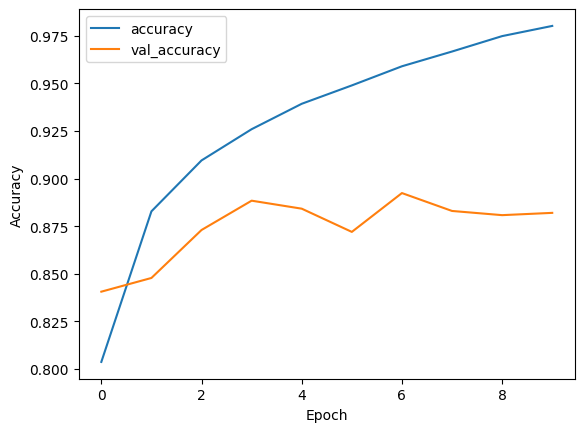

In [21]:
history3 = model3.fit(x_train_int, y_train, epochs=10, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

plt.plot(history3.history['accuracy'], label='accuracy')
plt.plot(history3.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

The model with a GRU layer instead of LSTM converge later than the previous one, but it presents as a result a bit greater validation accuracy (89% vs 87%)

In [ ]:
model3.save('model_3.h5')

In [22]:
history_df = pd.DataFrame(history3.history)
history_df.to_csv('training_history_model_3.csv', index=False)

**MODEL 4**

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5049 - loss: 0.6934 - val_accuracy: 0.5272 - val_loss: 0.6929
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5116 - loss: 0.6929 - val_accuracy: 0.5268 - val_loss: 0.6919
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5516 - loss: 0.6784 - val_accuracy: 0.7112 - val_loss: 0.5895
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7960 - loss: 0.4714 - val_accuracy: 0.8384 - val_loss: 0.3741
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9020 - loss: 0.2623 - val_accuracy: 0.8756 - val_loss: 0.3155
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9398 - loss: 0.1763 - val_accuracy: 0.8792 - val_loss: 0.3177
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9675 - loss: 0.1092 - val_accuracy: 0.8712 - val_loss: 0.3594
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9806 - loss: 0.0744 - val_accu

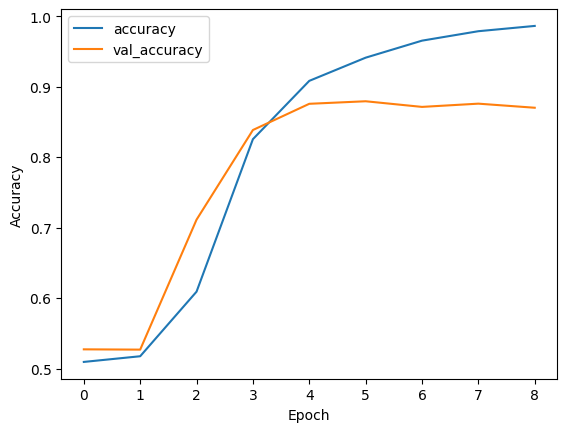

In [23]:
history4 = model4.fit(x_train_int, y_train, epochs=10, batch_size=128, validation_split=0.2, callbacks=[early_stopping])

plt.plot(history4.history['accuracy'], label='accuracy')
plt.plot(history4.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Results presented with both GRU and LSTM layers in the model are similar to the first one, but needing a larger number of epochs to converge.

In [ ]:
model4.save('model_4.h5')

In [24]:
history_df = pd.DataFrame(history4.history)
history_df.to_csv('training_history_model_4.csv', index=False)

**MODEL 5**

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6879 - loss: 0.5302 - val_accuracy: 0.8796 - val_loss: 0.2784
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8973 - loss: 0.2579 - val_accuracy: 0.8730 - val_loss: 0.3179
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9524 - loss: 0.1360 - val_accuracy: 0.8690 - val_loss: 0.3339
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9764 - loss: 0.0777 - val_accuracy: 0.8618 - val_loss: 0.4166


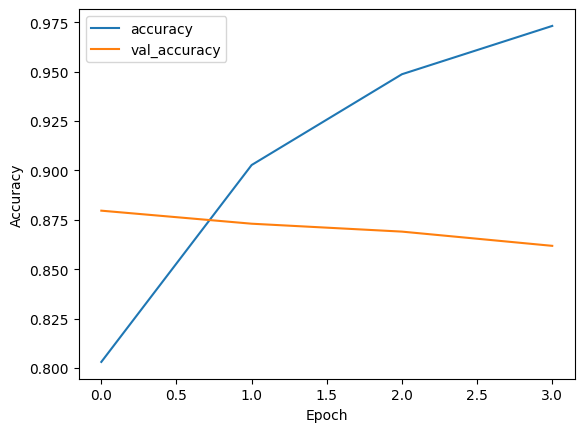

In [25]:
history5 = model5.fit(x_train_int, y_train, epochs=10, batch_size=64, validation_split=0.2, callbacks=[early_stopping])

plt.plot(history5.history['accuracy'], label='accuracy')
plt.plot(history5.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In this final model, looking at this graph we can deduce that using Convolutional and MaxPooling layers helps to converge more quickly (only need a few number of epochs), and the results of the accuracy are not necessarily lower.

In [ ]:
model5.save('model_5.h5')

In [26]:
history_df = pd.DataFrame(history5.history)
history_df.to_csv('training_history_model_5.csv', index=False)

### Evaluating the models

Next, we are going to see more the obtained values of accuracy and loss in the evaluation, but in general, the tendency explained above is followed.

**MODEL 1**

In [27]:
loss, accuracy = model1.evaluate(x_test_int, y_test)
print(f"Test accuracy: {accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8812 - loss: 0.2891
Test accuracy: 0.8768


**MODEL 2**

In [28]:
loss, accuracy = model2.evaluate(x_test_int, y_test)
print(f"Test accuracy: {accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8758 - loss: 0.2989
Test accuracy: 0.8745


**MODEL 3**

In [29]:
loss, accuracy = model3.evaluate(x_test_int, y_test)
print(f"Test accuracy: {accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8913 - loss: 0.2959
Test accuracy: 0.8894


**MODEL 4**

In [30]:
loss, accuracy = model4.evaluate(x_test_int, y_test)
print(f"Test accuracy: {accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8824 - loss: 0.3054
Test accuracy: 0.8782


**MODEL 5**

In [31]:
loss, accuracy = model5.evaluate(x_test_int, y_test)
print(f"Test accuracy: {accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8916 - loss: 0.2707
Test accuracy: 0.8895
